# # 6 - 311 Service Requests

The following notebook draws on street-vendor related 311 service requests (non-emergency reports submitted to the city government) to complement analysis done on the OATH dataset in previous notebooks. Many 311 requests relate to street vending related complaints, and could possibly result in a ticket once handled by an enforcing agent. The 311 request data extends only between 2010 and 2025 instead of a 1998 to 2025 time period. The notebook is broken down into the following sections:

#### Pulling 311 Request Data

Using public data from https://opendata.cityofnewyork.us/, a function is used to pull the 2010-2019 and 2020-2025 using an API. The two datasets are then combined to form the principal analysis dataset, `requests_2010_2025`.

**311 Request EDA**

* **Spatial Distribution**: Using a Kernel Density Estimation map, we see that 311 requests are very concentrated in lower Manhattan
* **Breakdown by Responding Agency**: Response to vendor related 311 requests is split between three agencies; the Department of Parks and Recreation, the Department of Sanitation, and the Department of Health and Mental Hygiene. The Department of Sanitation handles the majority of cases at 65.1%. Unlike violations in the OATH dataset, the NYPD do not respond to 311 requests. 
* **Breakdown by Time and Borough**: As shown in the Kernel Density Estimation map, Manhattan has the highest concentration of 311 requests at 56.2%, followed by Brooklyn and Queens at around 17%. Across time, we see requests remaining low, increasing to a couple thousand a year in 2018 and then experiencing a massive spike in 2023 to 20000 requests a year and continuing to increase to 2025 to around 35000 requests. 
* **Breakdown by Mayoral Administration**: The spike in requests in recent years is mirrored in the share across mayoral agencies. 87.4% of 311 requests occured under mayor Adams, followed by 11.4% under de Blasio. This extreme increase of requests in recent years could be one factor behind the increase in vending violations as seen in the OATH dataset.

**Matching 311 Service Requests with Violation Points**

Using the principal `violations_df_full` dataset, this section compares the match rate of the latitude and longitue coordinates of the violation points and the 311 requests as the coordinates get more and more precise. 

In [ ]:
# Setup

# Imports

import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath("..")) 
from src.fetch_analysis_311 import *
from src.enforcement_patterns import plot_kde_map

# Loading

FIGURES_DIR = "../outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)

RAW_DATA_DIR = "../data/raw"
os.makedirs(RAW_DATA_DIR, exist_ok=True)

nycc = gpd.read_file(f"{RAW_DATA_DIR}/council_districts/nycc.shp") # Council district shapefile

PRO_DATA_DIR = "../data/processed"
os.makedirs(PRO_DATA_DIR, exist_ok=True)

violations_df_full = pd.read_csv(f"{PRO_DATA_DIR}/violations_df_full.csv", low_memory = False) # Full violations dataframe
violations_df_full['violation_date'] = pd.to_datetime(violations_df_full['violation_date'], format = "mixed")
violations_df_full['year'] = violations_df_full['violation_date'].dt.year

cc_analysis = gpd.read_file(f"{PRO_DATA_DIR}/cc_analysis.geojson") # Council district analysis dataframe

## Pulling 311 Request Data

In [ ]:
# Pulling 2020 - 2025

requests_2020_2025 = fetch_and_save(
    resource_id="erm2-nwe9",
    date_filter="created_date < '2026-01-01T00:00:00'",
    out_path=f"{DATA_DIR}/311_requests/requests_2020_2025.csv",
)

# Pulling 2010 - 2019

requests_2010_2019 = fetch_and_save(
    resource_id="76ig-c548",
    date_filter=None,
    out_path=f"{DATA_DIR}/311_requests/requests_2010_2019.csv",
)

[erm2-nwe9] Fetched 50000 rows so far...
[erm2-nwe9] Fetched 100000 rows so far...
[erm2-nwe9] Fetched 121139 rows so far...
[erm2-nwe9] Done. Total rows: 121139
[76ig-c548] Fetched 23024 rows so far...
[76ig-c548] Done. Total rows: 23024


In [ ]:
# Merging
requests_2010_2025 = pd.concat([requests_2010_2019, requests_2020_2025], ignore_index = True)

# Filtering the violation of park rules
vending_descriptors = ['Unlicensed Vendors', 'Food']

mask = (
    (requests_2010_2025['complaint_type'] != 'Violation of Park Rules') |  # keep all non-park rows
    (requests_2010_2025['descriptor'].isin(vending_descriptors))            # keep only vending park rows
)

requests_2010_2025 = requests_2010_2025[mask]

requests_2010_2025 = gpd.GeoDataFrame(requests_2010_2025,
                                      geometry=gpd.points_from_xy(requests_2010_2025['longitude'], requests_2010_2025['latitude']),
                                      crs = "EPSG:4326").to_crs("EPSG:2263")

requests_2010_2025.to_csv(f"{RAW_DATA_DIR}/311_requests/requests_2010_2025.csv", index = False)


In [14]:
# Saving a sample

SAMPLE_DIR = "../data/sample"
os.makedirs(SAMPLE_DIR, exist_ok=True)
requests_2010_2025.sample(100).to_csv(f"{SAMPLE_DIR}/requests_2010_2025.csv", index=False)

## 311 Request EDA

**Spatial Distribution**

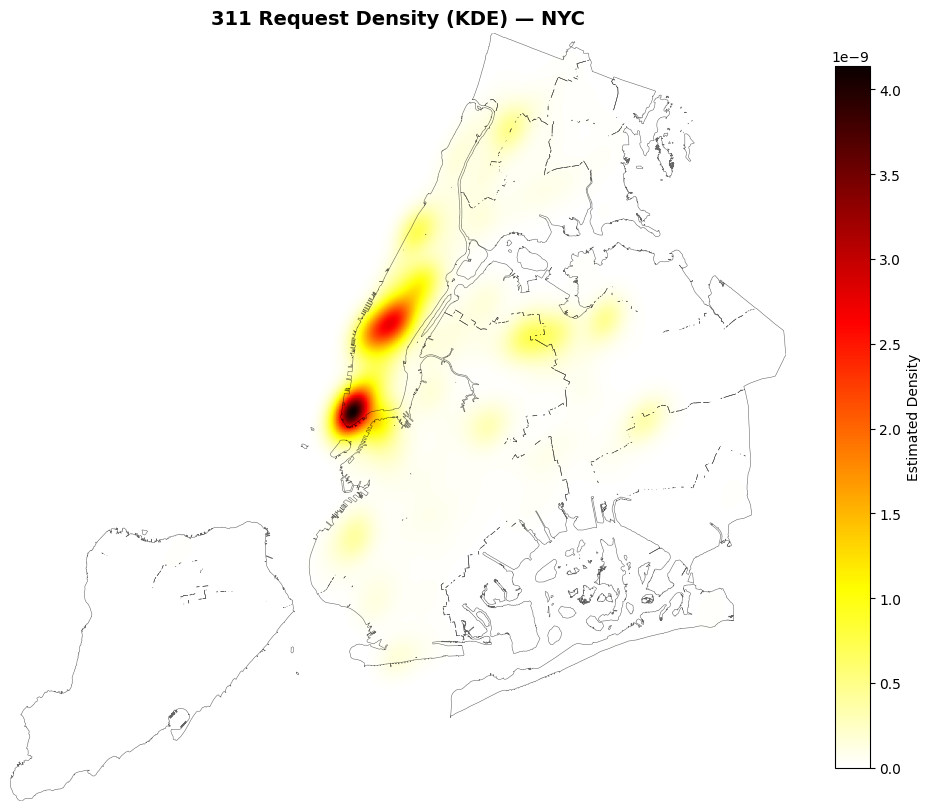

In [ ]:
# KDE Map
fig, ax = plt.subplots(figsize=(8, 10))

plot_kde_map(
    requests_2010_2025_gdf,
    boundary_gdf=nycc.dissolve(),
    title='311 Request Density (KDE) — NYC',
    ax=ax
)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/311_request_density.png")
plt.show()

**Breakdown by Responding Agency**

<Axes: title={'center': '311 Requests by Agency'}>

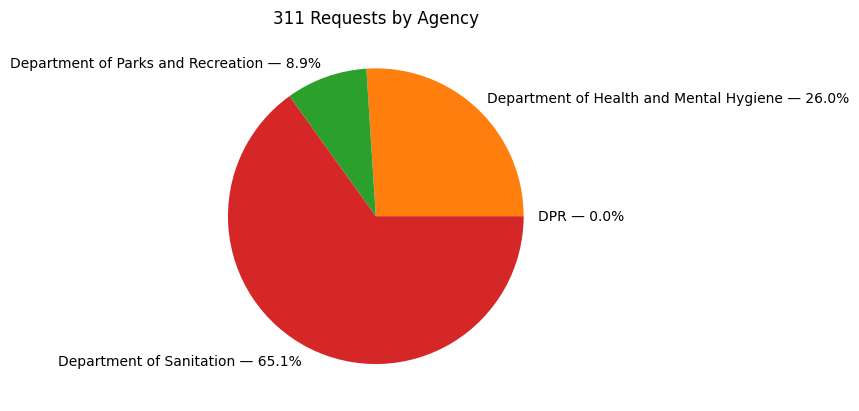

In [ ]:
# Pie chart of agency proportions 

agency_grouped = requests_2010_2025.groupby("agency_name").size()

total = agency_grouped.sum()
labels = [f"{name} — {count/total*100:.1f}%"
          for name, count in agency_grouped.items()]

agency_grouped.plot(kind="pie", labels=labels, ylabel="", title = "311 Requests by Agency")

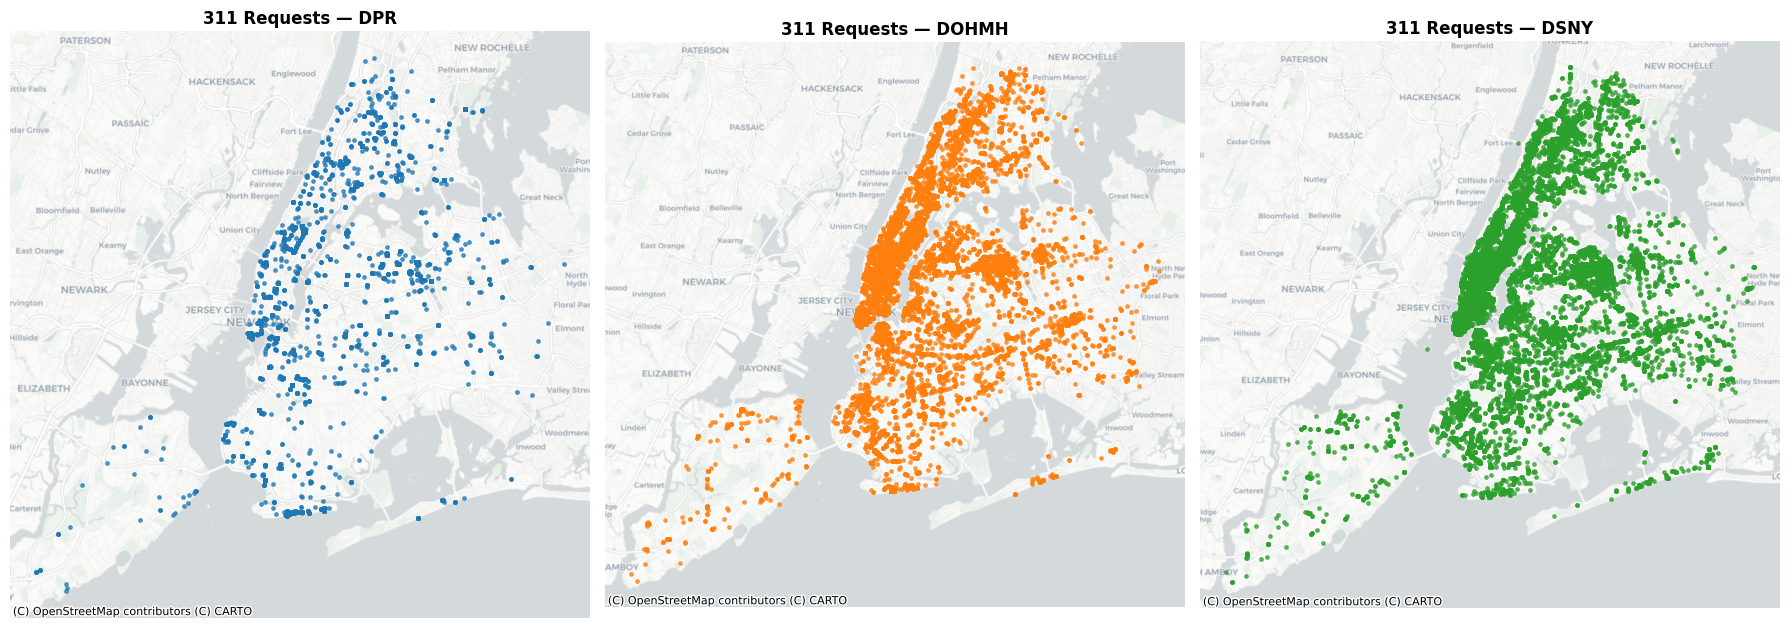

<Figure size 640x480 with 0 Axes>

In [ ]:
# Spatial Breakdown by Agency

agencies = ['DPR', 'DOHMH', 'DSNY']
map = plot_all_maps(requests_2010_2025_gdf, agencies)
plt.savefig(f"{FIGURES_DIR}/311_agency_breakdown.png")
map

**Breakdown by Time and Borough**

<Figure size 800x400 with 0 Axes>

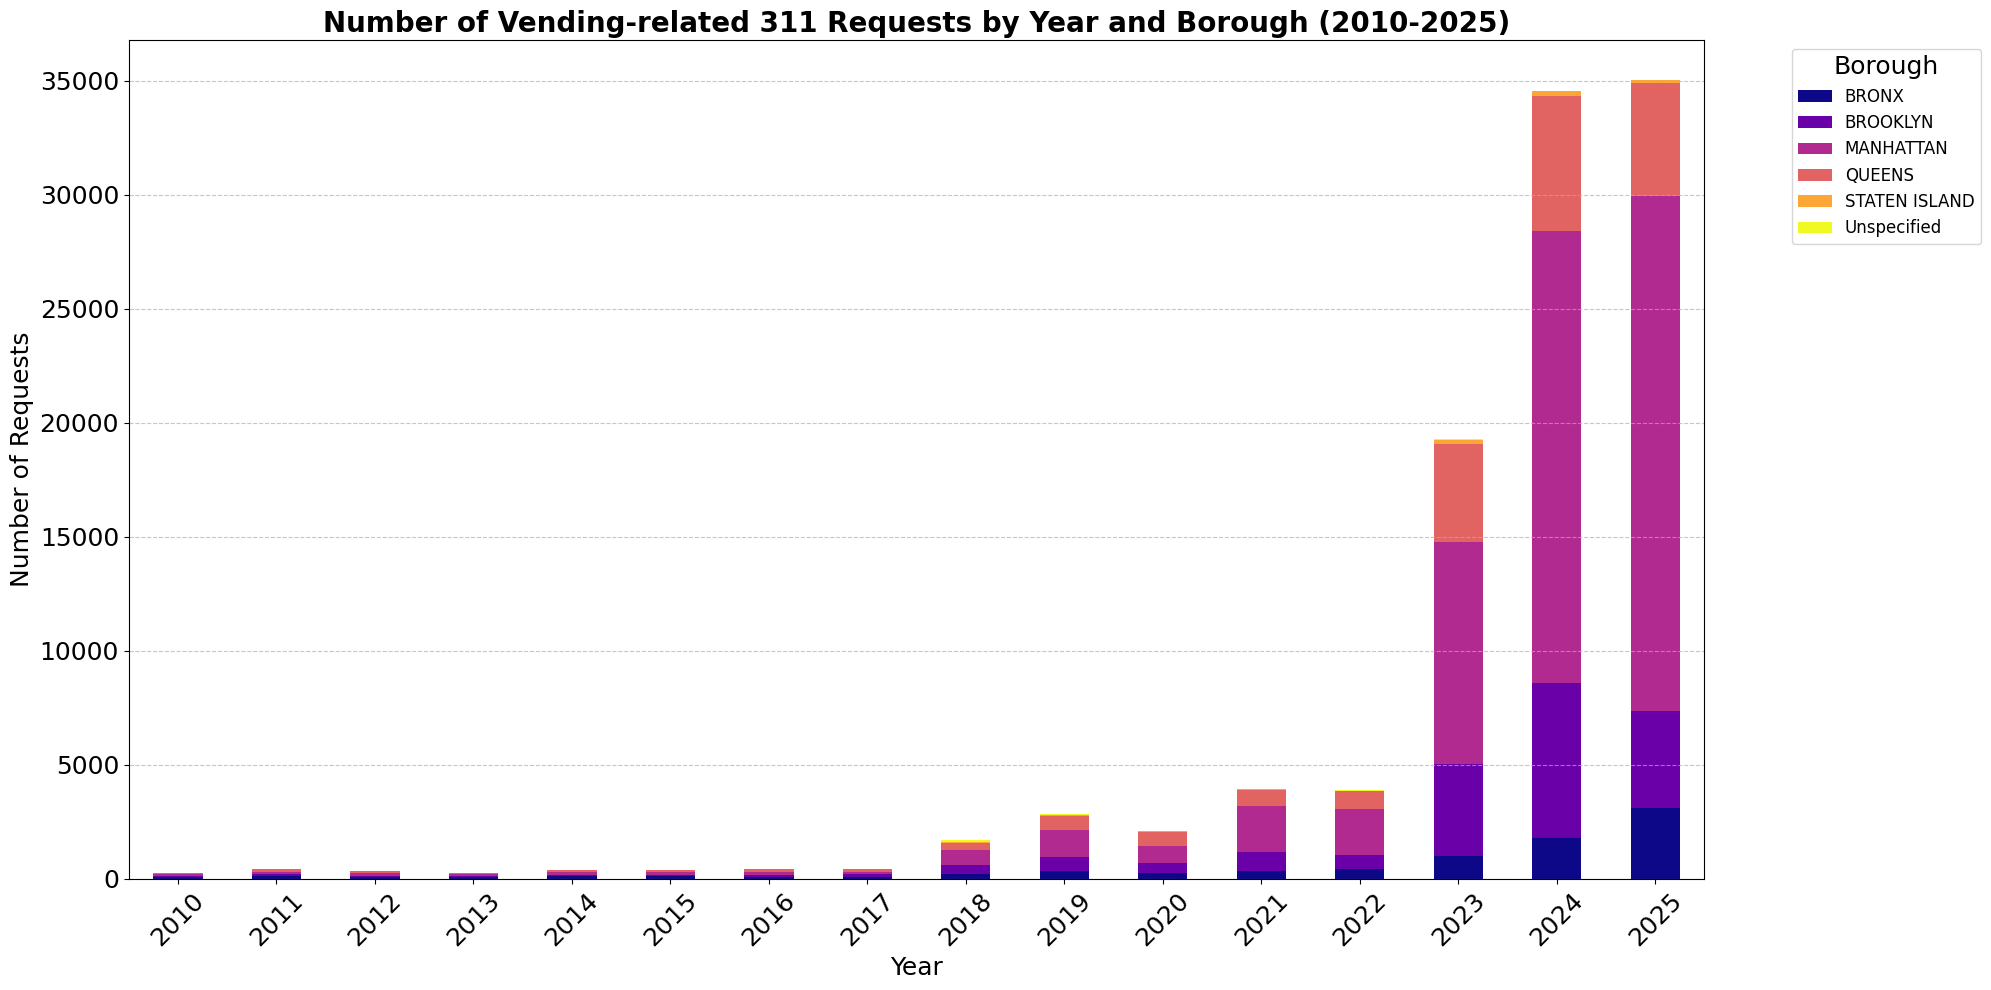

In [42]:
# Creating stacked bar chart of breakdown by borough over time

requests_2010_2025['year'] = pd.to_datetime(requests_2010_2025['created_date']).dt.year

# Group by year and borough, count violations
borough_counts = requests_2010_2025.groupby(['year', 'borough']).size().unstack(fill_value=0)

# Reindex to include all years in range even if some are missing
all_years = list(range(2010, 2026))
borough_counts = borough_counts.reindex(all_years, fill_value=0)

# Plotting
plt.figure(figsize=(8,4))
borough_counts.plot(kind='bar', stacked=True, figsize=(20,10),
                   colormap='plasma')

plt.title("Number of Vending-related 311 Requests by Year and Borough (2010-2025)",
          fontsize=20, fontweight='bold')  # Larger title font
plt.xlabel("Year", fontsize=18)  # Larger x-axis label
plt.ylabel("Number of Requests", fontsize=18)  # Larger y-axis label
plt.xticks(rotation=45, fontsize=18)  # Larger year labels
plt.yticks(fontsize=18)  # Larger y-axis numbers
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Borough', bbox_to_anchor=(1.05, 1), loc='upper left',
           fontsize=12, title_fontsize=18)  # Larger legend fonts
plt.tight_layout()
plt.show()

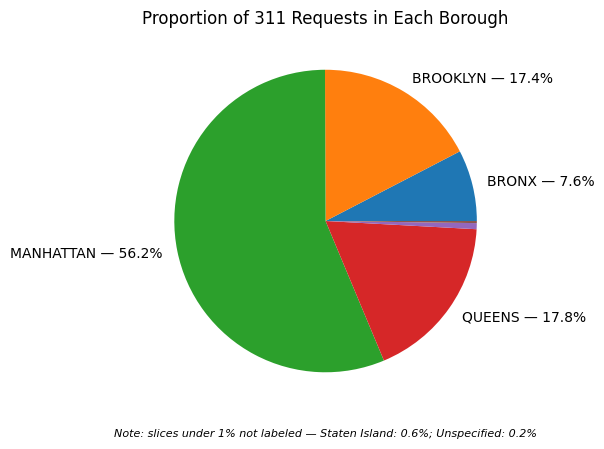

In [41]:
# Pie chart 

borough_grouped = requests_2010_2025.groupby("borough").size()

total = borough_grouped.sum()

# Only label slices above 1% directly on the pie
threshold = 1.0
labels = [
    f"{name} — {count/total*100:.1f}%" if (count/total*100) >= threshold else ""
    for name, count in borough_grouped.items()
]

fig, ax = plt.subplots(figsize=(6, 6))
borough_grouped.plot(kind="pie", labels=labels, ylabel="", ax=ax)

# Footnote for the small/excluded-from-label slices
small = borough_grouped[borough_grouped / total * 100 < threshold]
footnote = "; ".join(
    f"{name.title()}: {count/total*100:.1f}%" for name, count in small.items()
)
ax.annotate(
    f"Note: slices under {threshold:.0f}% not labeled — {footnote}",
    xy=(0.5, -0.05), xycoords="axes fraction",
    ha="center", va="top", fontsize=8, style="italic"
)

plt.title("Proportion of 311 Requests in Each Borough")
plt.tight_layout()
plt.show()

**Breakdown by Mayoral Administration**

In [43]:
# Creating an administration column

import numpy as np

administration = [
    requests_2010_2025['year'] < 2002,
    requests_2010_2025['year'].between(2002, 2013),
    requests_2010_2025['year'].between(2014, 2021),
    requests_2010_2025['year'].between(2022, 2025),
    requests_2010_2025['year'] > 2025
]

values = ["Giuliani", "Bloomberg", "de Blasio", "Adams", "Mamdani"]

requests_2010_2025['administration'] = np.select(administration, values, default="unknown")

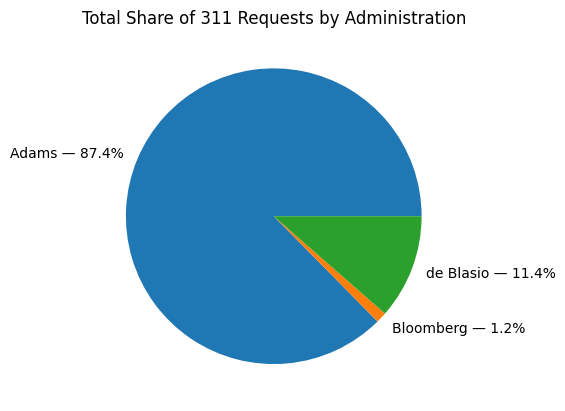

In [44]:
# Pie chart 

administration_grouped = requests_2010_2025.groupby("administration").size()

total = administration_grouped.sum()
labels = [f"{name} — {count/total*100:.1f}%"
          for name, count in administration_grouped.items()]

administration_grouped.plot(
    kind="pie",
    labels=labels,
    ylabel="",
    title="Total Share of 311 Requests by Administration"
)

plt.show()

## Matching 311 Service Requests with Violation Points

In [54]:
# Matching time periods with 311 requests

violations_311_match = violations_df_full[(violations_df_full['year'] >= 2010) & (violations_df_full['year'] <= 2025)]

In [56]:
# Approximate distance represented by each decimal place at NYC latitude
decimal_distances = {
    6: "~4.3 in",
    5: "~3.6 ft",
    4: "~36 ft",
    3: "~364 ft",
    2: "~0.7 mi",
    1: "~7 mi",
    0: "~69 mi"
}

total_requests = len(requests_2010_2025)
total_violations = len(violations_311_match)

rows = []
prev_rate = 0

for decimals in range(6, -1, -1):
    req = requests_2010_2025.copy()
    viol = violations_311_match.copy()

    req['lat_r'] = req['latitude'].astype(float).round(decimals)
    req['lon_r'] = req['longitude'].astype(float).round(decimals)
    req['date'] = pd.to_datetime(req['created_date']).dt.date

    viol['lat_r'] = viol['v_matched_lat'].astype(float).round(decimals)
    viol['lon_r'] = viol['v_matched_lon'].astype(float).round(decimals)
    viol['date'] = pd.to_datetime(viol['violation_date']).dt.date

    matched = req.merge(viol, on=['date', 'lat_r', 'lon_r'], how='inner')
    req['matched'] = req.index.isin(
    req.merge(viol, on=['date', 'lat_r', 'lon_r'], how='inner').index)
    n_matched = req['matched'].sum()
    match_rate = n_matched / total_requests

    rows.append({
        "Decimal Places": decimals,
        "Distance Represented": decimal_distances[decimals],
        "Total 311 Requests": total_requests,
        "Total Violations": total_violations,
        "Matched": n_matched,
        "Match Rate": f"{match_rate:.1%}",
        "Match Rate Increase": f"+{(match_rate - prev_rate):.1%}" if prev_rate > 0 else "—"
    })

    prev_rate = match_rate

sensitivity_df = pd.DataFrame(rows).set_index("Decimal Places")
sensitivity_df.to_csv(f"{DATA_DIR}/sensitivity_311_to_violations.csv")
sensitivity_df

,Distance Represented,Total 311 Requests,Total Violations,Matched,Match Rate,Match Rate Increase
Decimal Places,,,,,,
6,~4.3 in,106109,59624,3137,3.0%,—
5,~3.6 ft,106109,59624,3137,3.0%,+0.0%
4,~36 ft,106109,59624,3209,3.0%,+0.1%
3,~364 ft,106109,59624,4089,3.9%,+0.8%
2,~0.7 mi,106109,59624,31176,29.4%,+25.5%
1,~7 mi,106109,59624,106109,100.0%,+70.6%
0,~69 mi,106109,59624,106109,100.0%,+0.0%


## Aggregating by Council District

In [36]:
# Grouping by council district
cc_311 = requests_2010_2025[['unique_key', 'council_district']].groupby('council_district').agg('count').reset_index().rename(columns = {"unique_key": 'n_311_requests'})

# Merging back to cc_analysis
cc_analysis = cc_analysis.merge(
    cc_311,
    how = 'left',
    left_on = 'CounDist',
    right_on = 'council_district'
).drop(columns = ['council_district'])

**Saving Processed Dataframes**

In [40]:
cc_analysis.to_file(f"{PRO_DATA_DIR}/cc_analysis.geojson", driver = 'GeoJSON', index = False)